# Day 1 — EDA와 모델 전략

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from IPython.display import display, Image
import pandas as pd


In [2]:
from src.eda import run_day1
cells, summary, curves, traces, tables = run_day1()
display(tables["quality"])

Matplotlib is building the font cache; this may take a moment.


Reading Batch 1: 2017-05-12_batchdata_updated_struct_errorcorrect.mat


Batch 1 loaded


Reading Batch 2: 2018-02-20_batchdata_updated_struct_errorcorrect.mat


Batch 2 loaded


...


life_groups
  batch life_group  n  delta_log_var      Tavg  rate1
Batch 1 long >1000 10      -4.310746 31.541666    4.2
Batch 1     middle 36      -3.786476 33.022316    6.0
Batch 2 long >1000  3      -4.271782 33.929145    5.2
Batch 2     middle  8      -4.153341 33.402530    5.0
Batch 2 short <500 28      -3.446103 32.937446    5.2
Batch 3 long >1000 23      -4.316748 34.745836    5.3
Batch 3     middle 21      -4.091804 34.053411    5.6



short_cell_peers
  batch cell_id  cycle_life                      policy  peer_n  peer_life      Tavg  peer_Tavg  delta_log_var  peer_delta_log_var
Batch 1  B1_020       534.0              5.4C(80%)-5.4C       1      559.0 32.152922  33.136974      -3.367237           -3.350338
Batch 1  B1_021       559.0              5.4C(80%)-5.4C       1      534.0 33.136974  32.152922      -3.350338           -3.367237
Batch 1  B1_045       599.0                8C(35%)-3.6C       1      616.0 33.000547  32.553332      -3.425292           -3.420700
Batch 2  B2_019       392.0                  6C(60%)-3C       1      408.0 32.770067  33.601188      -3.291958           -3.326679
Batch 2  B2_006       393.0                 3.6C(9%)-5C       1      396.0 33.819045  32.862748      -3.530040           -3.516252
Batch 2  B2_015       396.0                 3.6C(9%)-5C       1      393.0 32.862748  33.819045      -3.516252           -3.530040
Batch 3  B3_028       541.0 3.7C(31%)-5.9C-newstructure       2  


knee_sensitivity
  batch  window  count  median
Batch 1      11     45   610.0
Batch 2      11     39   340.0
Batch 3      11     44   817.5
Batch 1      21     45   610.0
Batch 2      21     39   340.0
Batch 3      21     44   817.5
Batch 1      41     45   605.0
Batch 2      41     39   335.0
Batch 3      41     44   817.5



TOP CORRELATIONS
  batch       feature  n  spearman   pearson  abs_rho
Batch 1  charge_I_std 46 -0.873628 -0.896206 0.873628
Batch 1 delta_log_var 46 -0.871161 -0.886123 0.871161
Batch 1     delta_std 46 -0.871161 -0.893713 0.871161
Batch 1     delta_min 46  0.850006  0.881645 0.850006
Batch 1    delta_mean 46  0.828112  0.853810 0.828112
Batch 3     delta_std 44 -0.797237 -0.672606 0.797237
Batch 3 delta_log_var 44 -0.797237 -0.701862 0.797237
Batch 3     delta_min 44  0.776024  0.692116 0.776024
Batch 3    delta_mean 44  0.756149  0.639115 0.756149
Batch 2     delta_std 39 -0.708979 -0.834546 0.708979
Batch 2 delta_log_var 39 -0.708979 -0.901883 0.708979
Batch 2    delta_mean 39  0.697237  0.767085 0.697237
Batch 2     delta_min 39  0.660897  0.818518 0.660897
Batch 3  charge_I_p95 44 -0.601099 -0.707691 0.601099
Batch 2 charge_I_mean 39  0.538314  0.836165 0.538314


,batch,placeholder_rows,endpoint_high_capacity_labeled,min_early_rows,incomplete_delta,IR_all_zero_cells,unparsed_policy,QD_over_1_3,nonfinite_QD
0,Batch 1,46,10,99,0,0,0,2,0
1,Batch 2,0,0,99,0,7,4,11,0
2,Batch 3,0,0,99,0,0,0,0,0


## 1. Cycle Life 분포

라벨 셀을 기준으로 단수명 <500회, 장수명 >1000회를 구분. IQR 이상치 계산은 하지만 제거하지는 않습니다.

In [3]:
display(tables['distribution'])
display(tables['short_cell_peers'])

,batch,total,labeled,missing,min,q1,median,mean,q3,max,std,skew,short_count,short_pct,long_count,long_pct,low_fence,high_fence,low_outliers,high_outliers
0,Batch 1,46,46,0,534.0,703.25,858.5,844.717391,914.25,1227.0,184.629198,0.452864,0,0.000000,10,21.739130,386.750,1230.750,0,0
1,Batch 2,47,39,8,392.0,439.50,472.0,565.743590,508.50,1186.0,222.201629,1.636830,28,71.794872,3,7.692308,336.000,612.000,0,9
2,Batch 3,46,44,2,541.0,828.00,1005.5,1059.659091,1155.25,1935.0,313.869692,1.255079,0,0.000000,23,52.272727,337.125,1646.125,0,3


,batch,cell_id,cycle_life,policy,peer_n,peer_life,Tavg,peer_Tavg,delta_log_var,peer_delta_log_var
0,Batch 1,B1_020,534.0,5.4C(80%)-5.4C,1,559.0,32.152922,33.136974,-3.367237,-3.350338
1,Batch 1,B1_021,559.0,5.4C(80%)-5.4C,1,534.0,33.136974,32.152922,-3.350338,-3.367237
2,Batch 1,B1_045,599.0,8C(35%)-3.6C,1,616.0,33.000547,32.553332,-3.425292,-3.420700
3,Batch 2,B2_019,392.0,6C(60%)-3C,1,408.0,32.770067,33.601188,-3.291958,-3.326679
4,Batch 2,B2_006,393.0,3.6C(9%)-5C,1,396.0,33.819045,32.862748,-3.530040,-3.516252
5,Batch 2,B2_015,396.0,3.6C(9%)-5C,1,393.0,32.862748,33.819045,-3.516252,-3.530040
6,Batch 3,B3_028,541.0,3.7C(31%)-5.9C-newstructure,2,719.5,35.696888,34.503802,-3.451658,-3.615017
7,Batch 3,B3_006,667.0,3.7C(31%)-5.9C-newstructure,2,656.5,34.107206,35.298644,-3.525708,-3.577992
8,Batch 3,B3_031,731.0,5.9C(60%)-3.1C-newstructure,1,1002.0,34.000031,34.610697,-3.839603,-4.046822


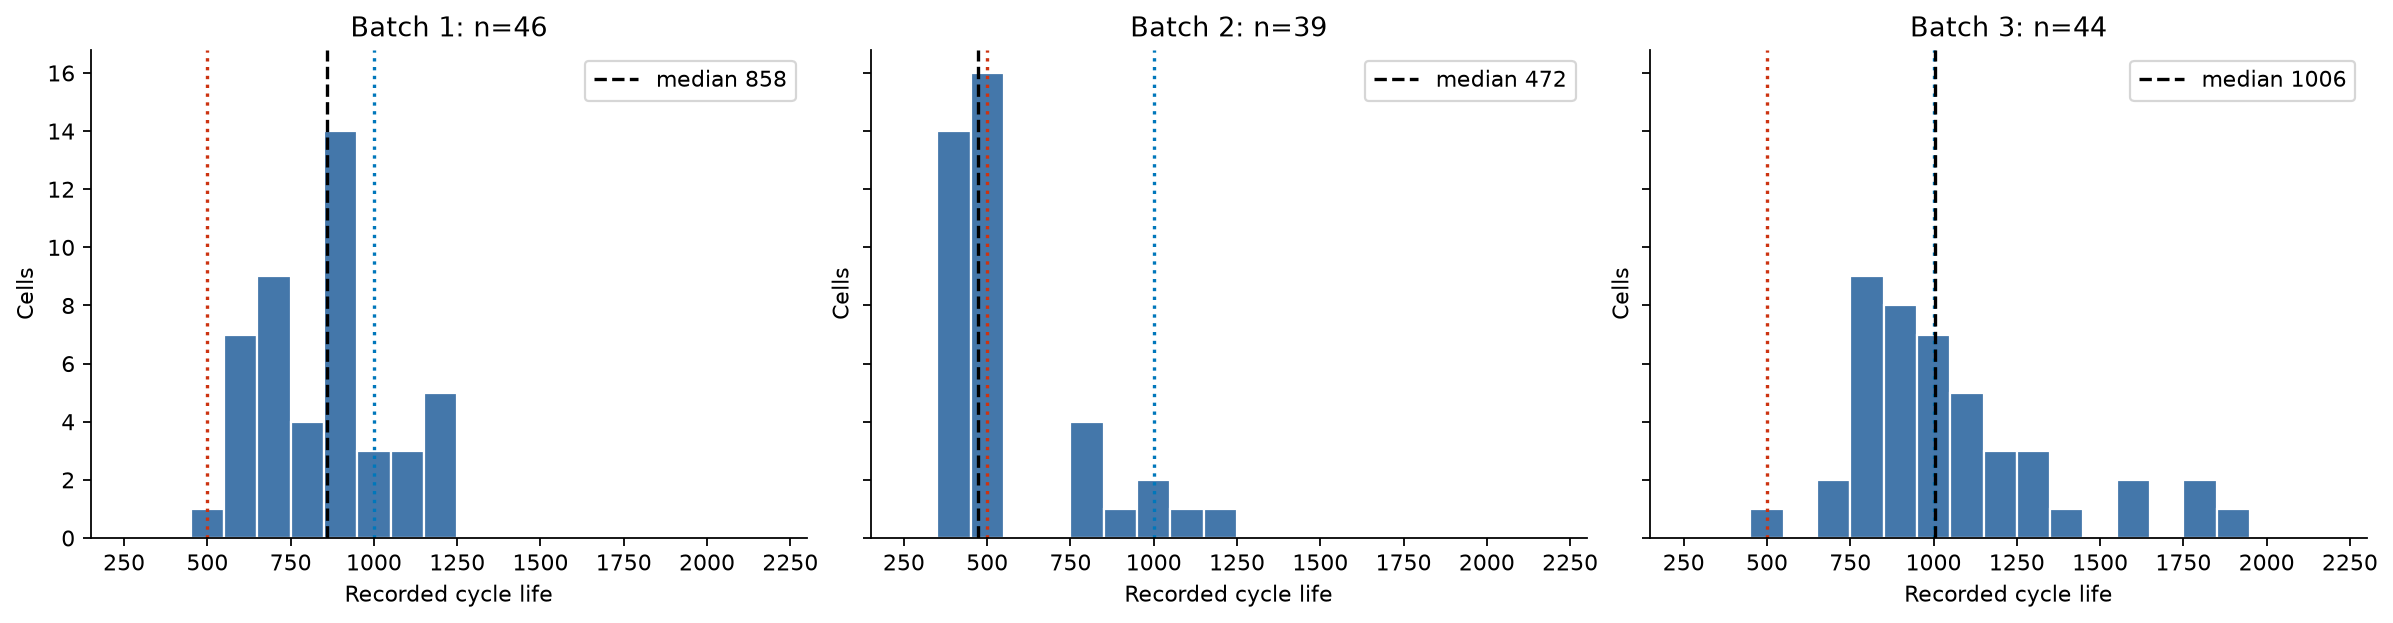

In [4]:
display(Image(filename=str(ROOT / "results/eda/figures/01_life.png")))

### 질문 1. Batch 1의 수명 분포와 최단수명 셀

- 수명 중앙값 858.5회, 단수명(<500회) 0셀, 장수명(>1000회) 10/46셀입니다.
- 최단 B1_020은 534회로 같은 정책의 다른 셀도 559회입니다. 온도만으로 짧은 수명을 설명하기 어렵습니다.
- 500회 기준 분류보다 수명 회귀를 선택합니다. 종료 용량이 높은 10셀의 라벨은 별도로 점검합니다.

### 질문 2. Batch 2의 수명 분포와 최단수명 셀

- 중앙값 472회, 단수명 28/39셀(71.8%)로 짧은 수명이 배치 전체의 특징입니다. 상단 IQR 이상치 9셀은 모두 `newstructure` 표기가 있습니다.
- 최단 B2_019은 392회이며 같은 정책의 다른 셀은 408회입니다. 낮은 첫 C-rate에서도 짧은 수명이 관찰됩니다.
- 단수명 셀을 일괄 제거하지 않고 충전 단계와 정책 집단을 함께 살펴봅니다.

### 질문 3. Batch 3의 수명 분포와 최단수명 셀

- 중앙값 1005.5회, 장수명 23/44셀(52.3%)입니다. 상단 IQR 이상치 3셀은 보존하고 라벨 없는 셀의 기록 길이는 수명으로 대체하지 않습니다.
- 최단 B3_028은 541회로 같은 정책의 다른 두 셀 중앙값보다 178.5회 짧습니다. 온도와 ΔQ에도 차이가 있지만 원인으로 확정할 수는 없습니다.
- 정책 외 초기 상태 피처를 검토하고 장수명 구간의 오차를 확인합니다.

## 2. 방전 용량 열화와 Knee

라벨까지 관측한 길이를 N으로 두고 중기(20~40%)·후기(60~80%)의 Theil–Sen 기울기를 비교합니다. 중기 기울기가 음수이고 후기 감소가 2배보다 빠르면 가속으로 분류합니다.

Knee는 21점 이동 중앙값·5사이클 간격으로 탐색합니다. 곡선의 20~85%에서 두 구간 직선을 적합해, 두 기울기가 음수이고 후기 감소가 2배 이상이며 단일 직선보다 제곱오차가 20% 이상 줄어드는 후보를 찾습니다.

In [5]:
display(tables['degradation'])
display(tables['knee_sensitivity'])

,batch,cells,accelerated,acceleration_pct,knee_n,knee_median,slope_mid_median,slope_late_median,current_vs_early,current_vs_late
0,Batch 1,46,39,84.782609,45,610.0,-0.000051,-0.000215,-0.416960,0.727906
1,Batch 2,39,26,66.666667,39,340.0,-0.000043,-0.000448,-0.201417,0.124899
2,Batch 3,44,34,77.272727,44,817.5,-0.000047,-0.000129,-0.480479,0.707681


,batch,window,count,median
0,Batch 1,11,45,610.0
1,Batch 2,11,39,340.0
2,Batch 3,11,44,817.5
3,Batch 1,21,45,610.0
4,Batch 2,21,39,340.0
5,Batch 3,21,44,817.5
6,Batch 1,41,45,605.0
7,Batch 2,41,39,335.0
8,Batch 3,41,44,817.5


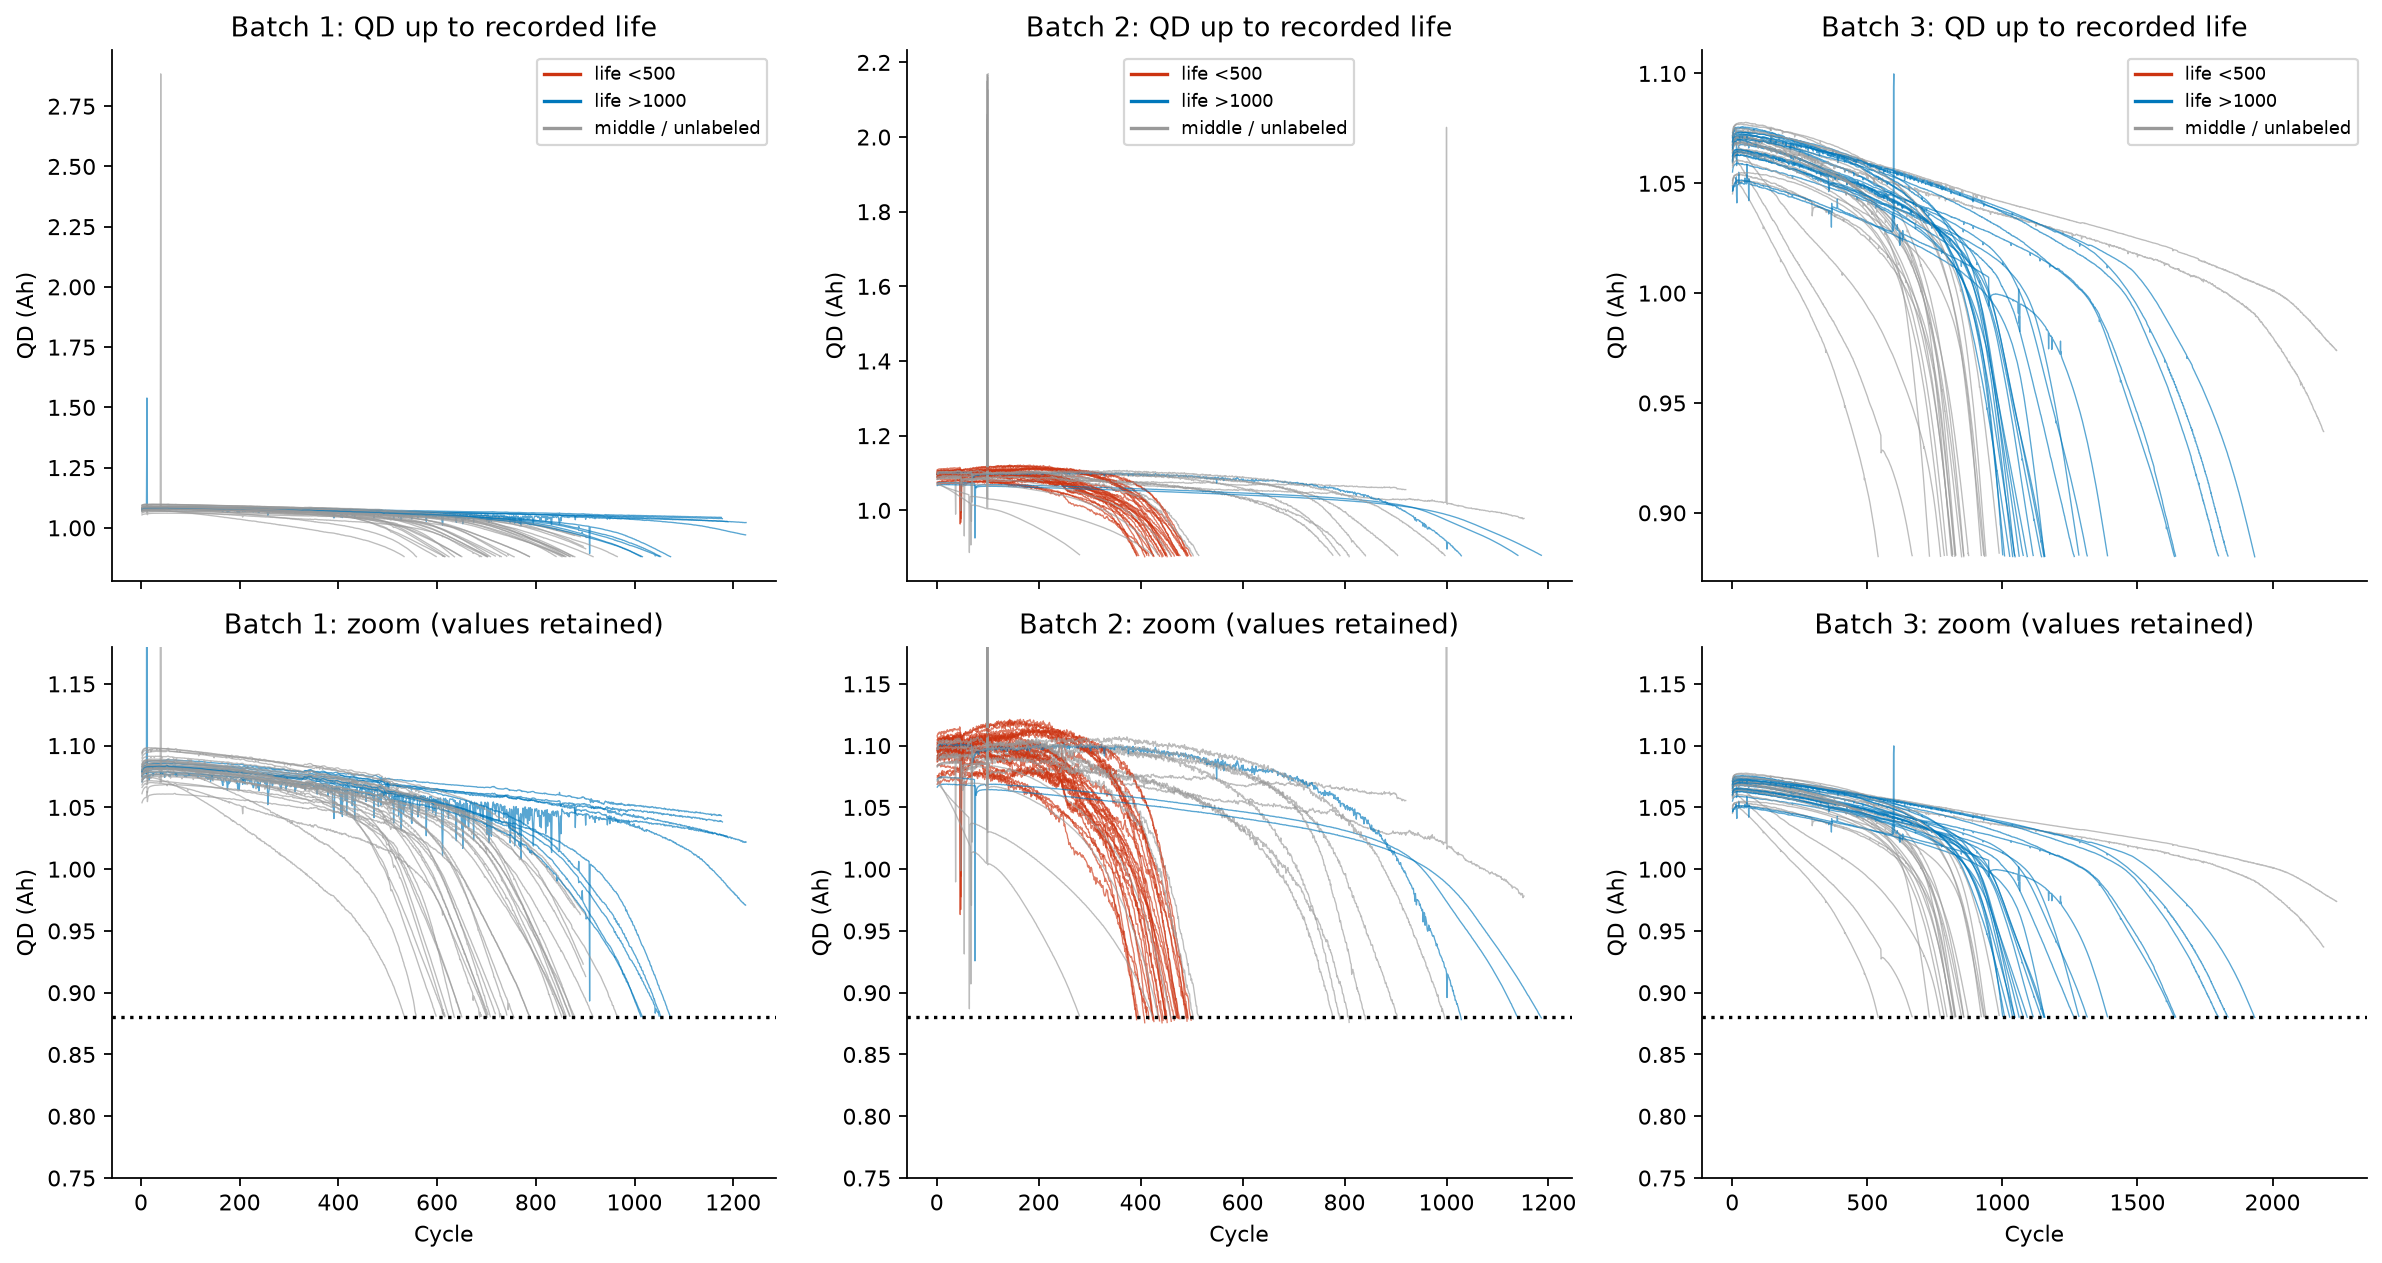

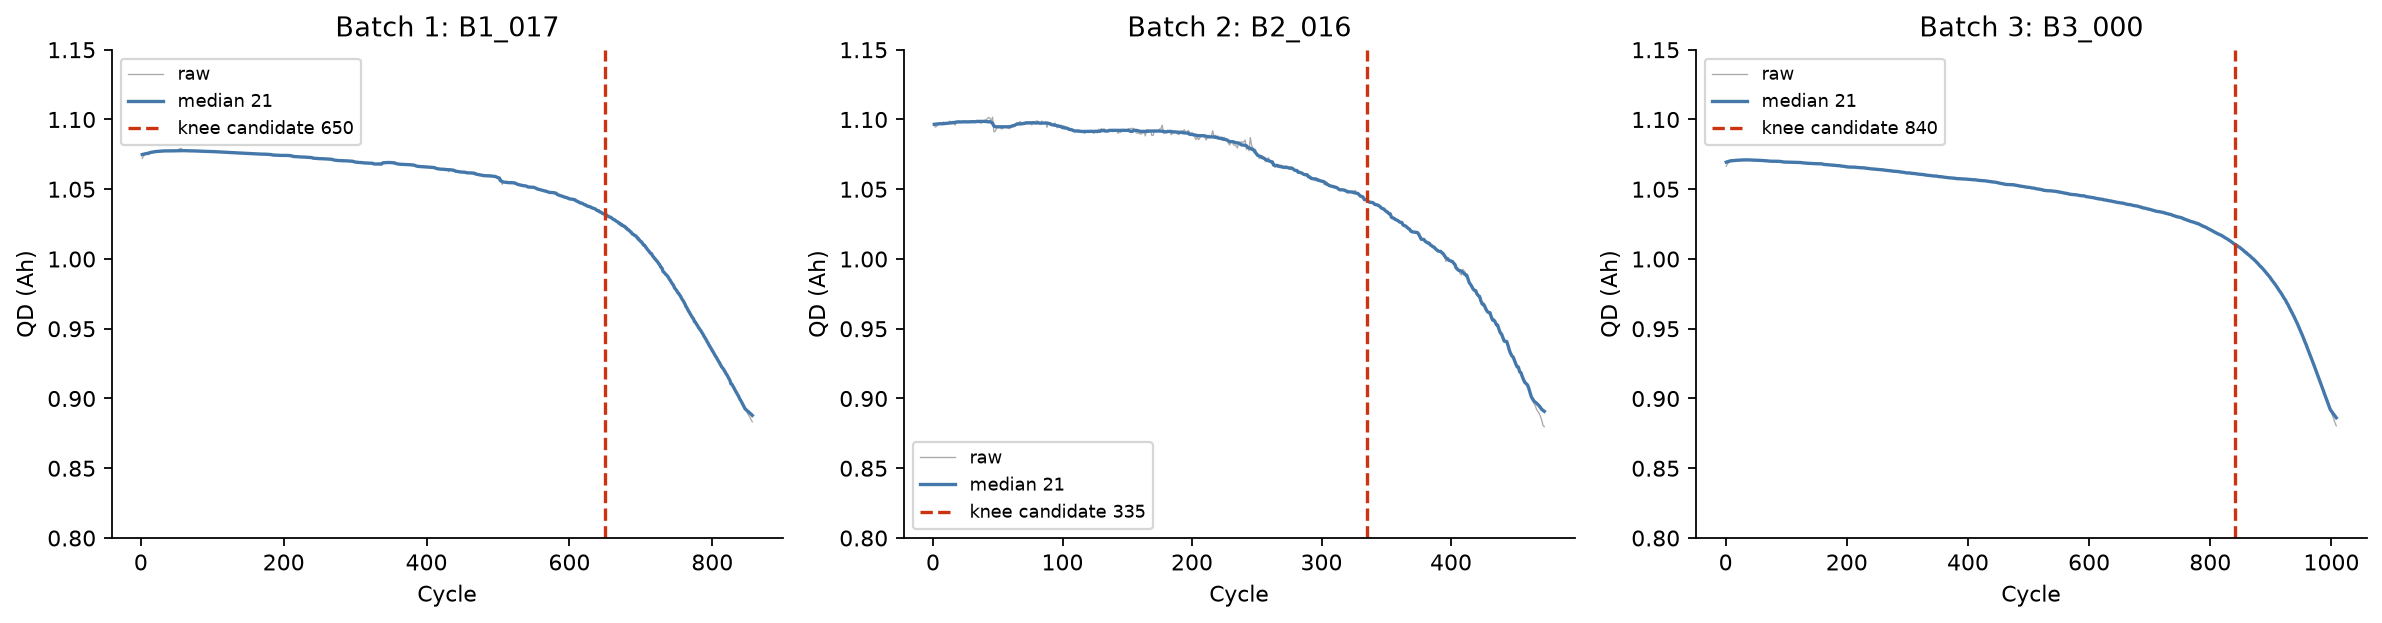

In [6]:
display(Image(filename=str(ROOT / "results/eda/figures/02_degradation.png")))
display(Image(filename=str(ROOT / "results/eda/figures/03_knee.png")))

### 질문 4. Batch 1의 용량 감소 패턴과 Knee 후보

- 39/46셀(84.8%)에서 후기 감소가 빨라졌고, Knee 후보는 45셀에서 검출됐습니다(중앙값 610회).
- 초기 QD 중앙값은 1.0825Ah입니다. 종료 용량이 높은 셀의 Knee는 관측 구간의 후보로 해석합니다.
- 초기 QD 기울기와 ΔQ를 후보로 사용하고, 전체 곡선에서 얻은 Knee는 입력에서 제외합니다.

### 질문 5. Batch 2의 용량 감소 패턴과 Knee 후보

- 26/39셀(66.7%)에서 감소가 가속됐으며 Knee 후보 중앙값은 340회로 가장 이릅니다.
- 초기 QD 기울기는 22/39셀에서 양수입니다. 초기 용량 증가가 긴 수명을 뜻하지는 않고, 열화 비교는 라벨 시점까지로 제한했습니다.
- QD 기울기의 부호를 보존하고 전압별 변화량인 ΔQ와 함께 검토합니다.

### 질문 6. Batch 3의 용량 감소 패턴과 Knee 후보

- 초기 QD 중앙값은 1.0677Ah로 낮지만 수명은 가장 깁니다. 가속은 34/44셀(77.3%), Knee 후보 중앙값은 817.5회입니다.
- 후기 기울기 중앙값은 −1.29e-04Ah/cycle로 Batch 2보다 완만합니다.
- 절대 초기 용량만으로 수명을 판단하지 않습니다. ΔQ를 기본으로 두고 정규화 용량 변화는 보조 후보로 검토합니다.

## 3. ΔQ(V)와 초기 피처

ΔQ(V)=Q100(V)−Q10(V)입니다. 원본 전압축 2.0~3.5V의 1,000점에 맞춰 비교하고, `log10(var(ΔQ))`를 계산합니다(ddof=0). Batch 1·3은 수명 사분위, Batch 2는 <500·>1000회 집단을 비교합니다.

In [7]:
from src.eda import delta_group_comparison
display(delta_group_comparison(cells).round(5))

,batch,group,n,delta_min_median,delta_log_var_median
0,Batch 1,수명 하위 사분위,12,-0.04893,-3.57731
1,Batch 1,수명 상위 사분위,12,-0.02684,-4.12520
2,Batch 2,단수명 <500회,28,-0.05618,-3.44610
3,Batch 2,장수명 >1000회,3,-0.01916,-4.27178
4,Batch 3,수명 하위 사분위,12,-0.02786,-4.07907
5,Batch 3,수명 상위 사분위,11,-0.01706,-4.45464


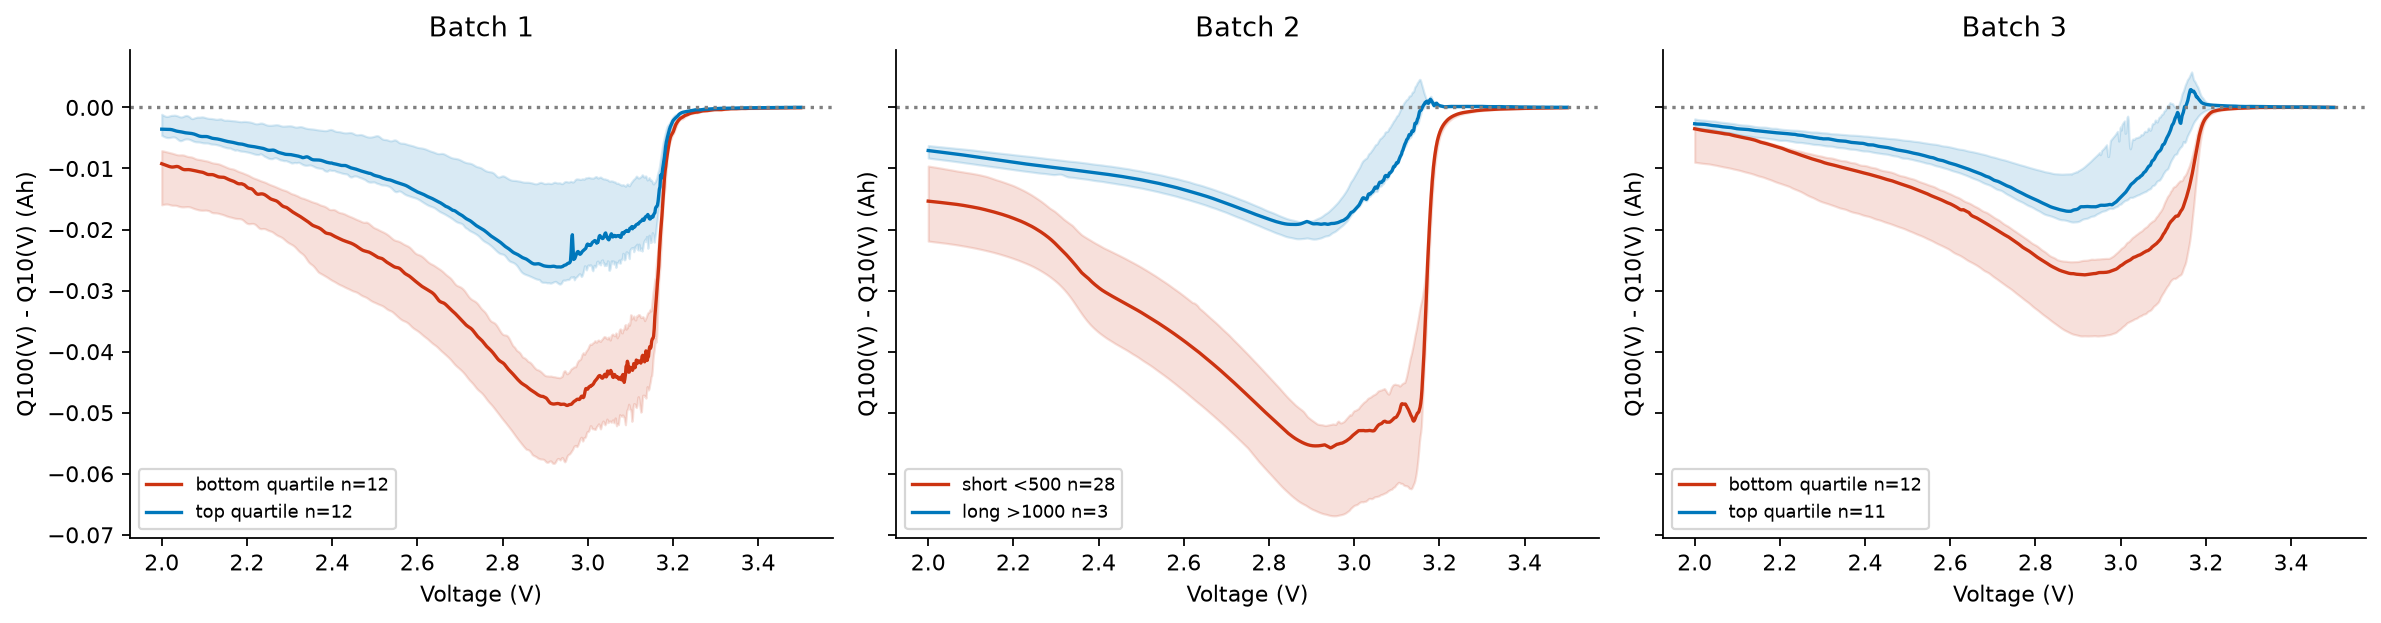

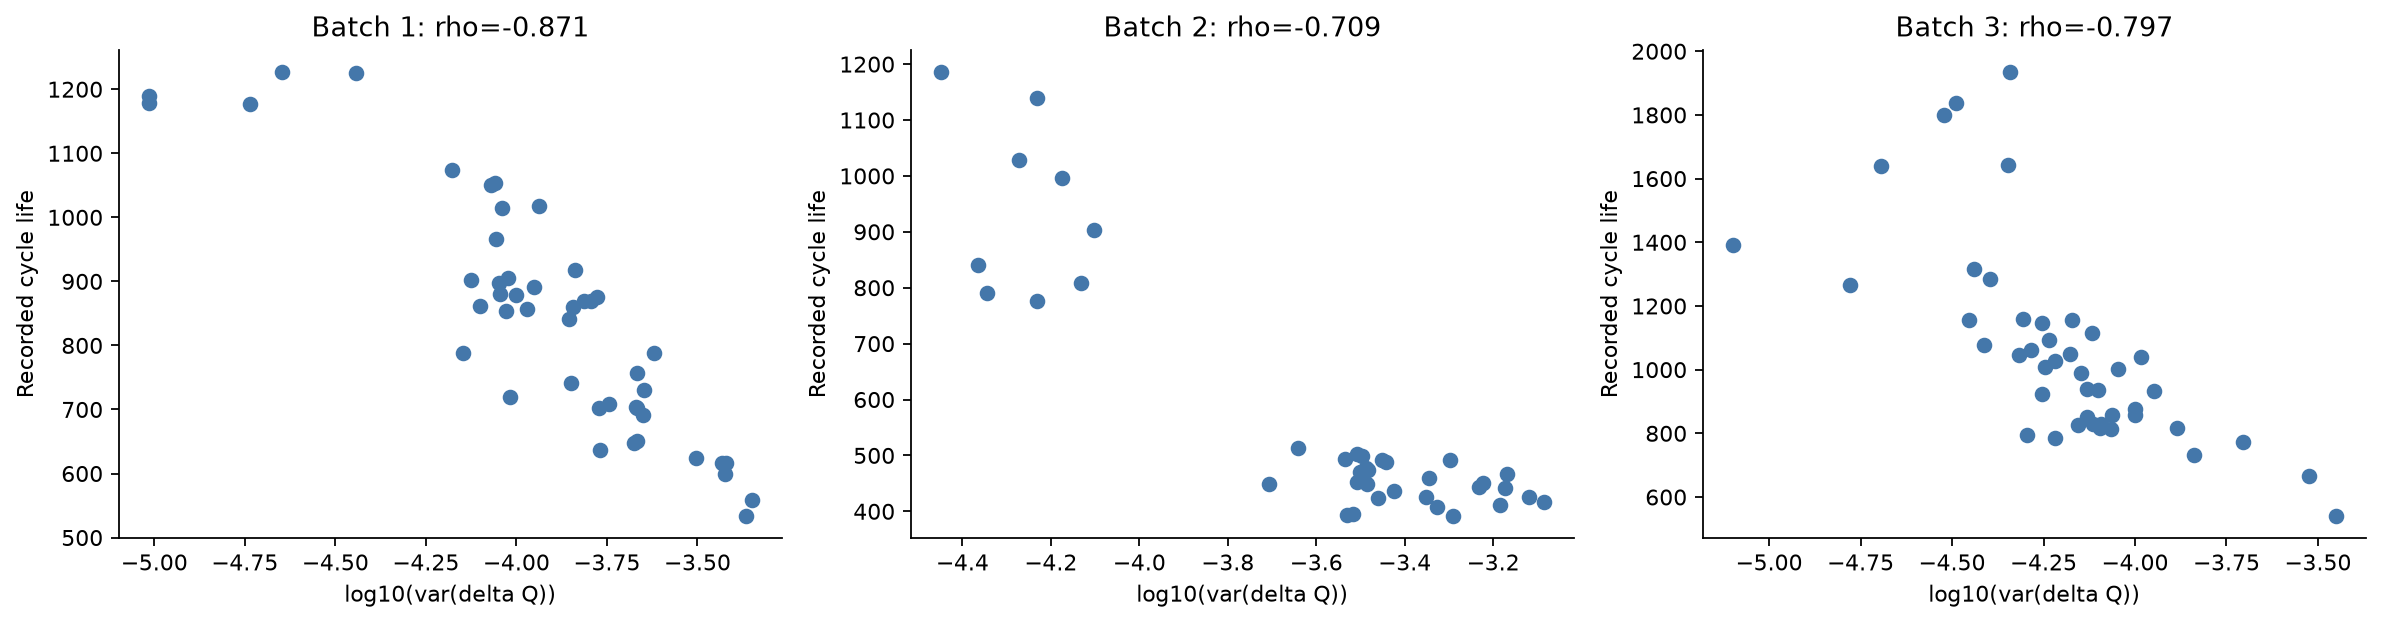

In [8]:
display(Image(filename=str(ROOT / "results/eda/figures/04_delta_q.png")))
display(Image(filename=str(ROOT / "results/eda/figures/05_delta_life.png")))

### 질문 7. Batch 1의 초기 ΔQ와 수명 차이

- <500회 셀이 없어 수명 하위·상위 사분위 집단을 비교했습니다(각 12셀). 하위 집단의 ΔQ가 더 음수였습니다.
- ΔQ 로그 분산–수명 ρ=−0.871로 초기 QD 평균의 +0.185보다 강했습니다.
- ΔQ 로그 분산을 기본 피처로 선정합니다. 이 비교는 배치 내 상대적인 수명 차이입니다.

### 질문 8. Batch 2의 초기 ΔQ와 수명 차이

- 단수명 28셀·장수명 3셀의 ΔQ 로그 분산 중앙값은 −3.446·−4.272로, 분산 규모는 약 6.7배 차이입니다. 수명과의 ρ는 −0.709입니다.
- 장수명 표본이 적고 정책 집단 구성도 달라 결과를 일반화할 때 주의가 필요합니다.
- ΔQ의 예측력은 그룹 검증과 배치 간 평가에서 확인합니다.

### 질문 9. Batch 3의 초기 ΔQ와 수명 차이

- 수명 하위 12셀·상위 11셀의 ΔQ 최솟값 중앙값은 −0.02786·−0.01706Ah입니다.
- ΔQ 로그 분산–수명 ρ=−0.797로 초기 QD 평균의 +0.162보다 강합니다. 하위 집단은 <500회 단수명 집단과 다릅니다.
- 장수명 비중이 높은 배치에서도 ΔQ를 기본 피처 후보로 유지합니다.

## 4. 충전 정책·전류와 수명

정책별 막대는 평균 수명, 오차막대는 표본 표준편차입니다. 실제 전류 통계는 cycle 10의 양의 충전 구간을 시간 가중해 계산합니다. p95는 높은 전류 구간을 나타내는 가중 백분위 근사입니다.

In [9]:
display(tables['policies'])

,batch,policy,n,mean_life,std_life,median_life
0,Batch 1,3.6C(80%)-3.6C,3,1182.000000,7.000000,1179.0
1,Batch 1,4.4C(80%)-4.4C,1,1074.000000,NaN,1074.0
2,Batch 1,4.8C(80%)-4.8C,2,753.000000,165.462987,753.0
3,Batch 1,4C(80%)-4C,2,1226.500000,0.707107,1226.5
4,Batch 1,5.4C(40%)-3.6C,2,966.500000,123.743687,966.5
5,Batch 1,5.4C(50%)-3.6C,2,899.500000,3.535534,899.5
6,Batch 1,5.4C(50%)-3C,2,847.000000,83.438600,847.0
7,Batch 1,5.4C(60%)-3.6C,2,859.500000,3.535534,859.5
8,Batch 1,5.4C(60%)-3C,2,799.500000,113.844192,799.5
9,Batch 1,5.4C(70%)-3C,2,739.500000,68.589358,739.5


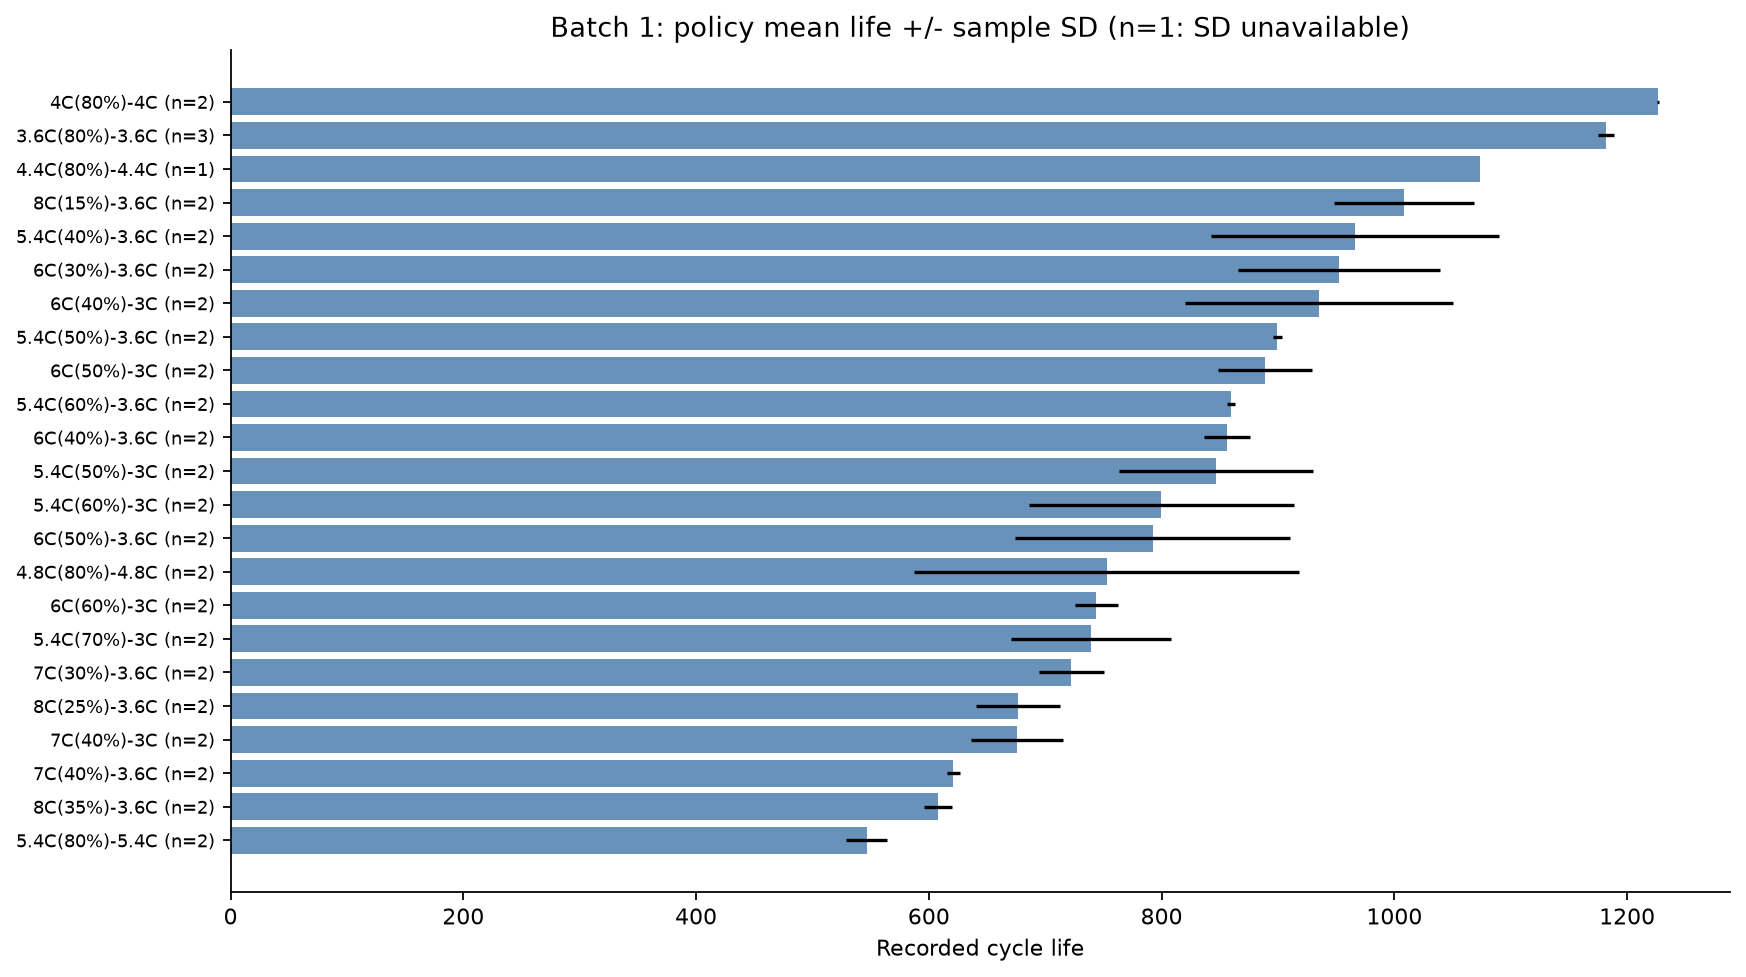

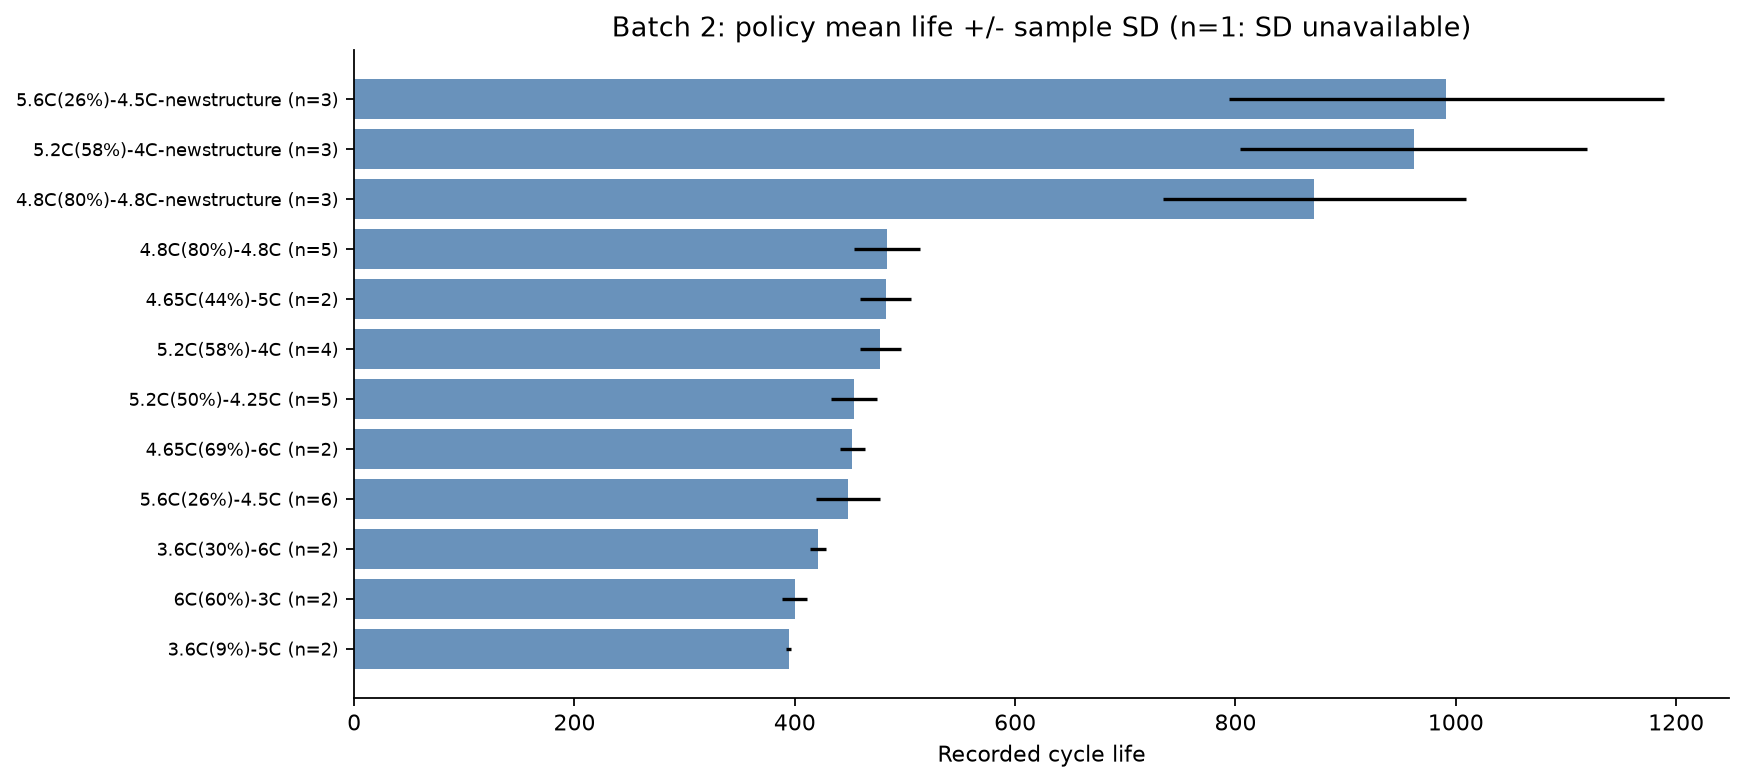

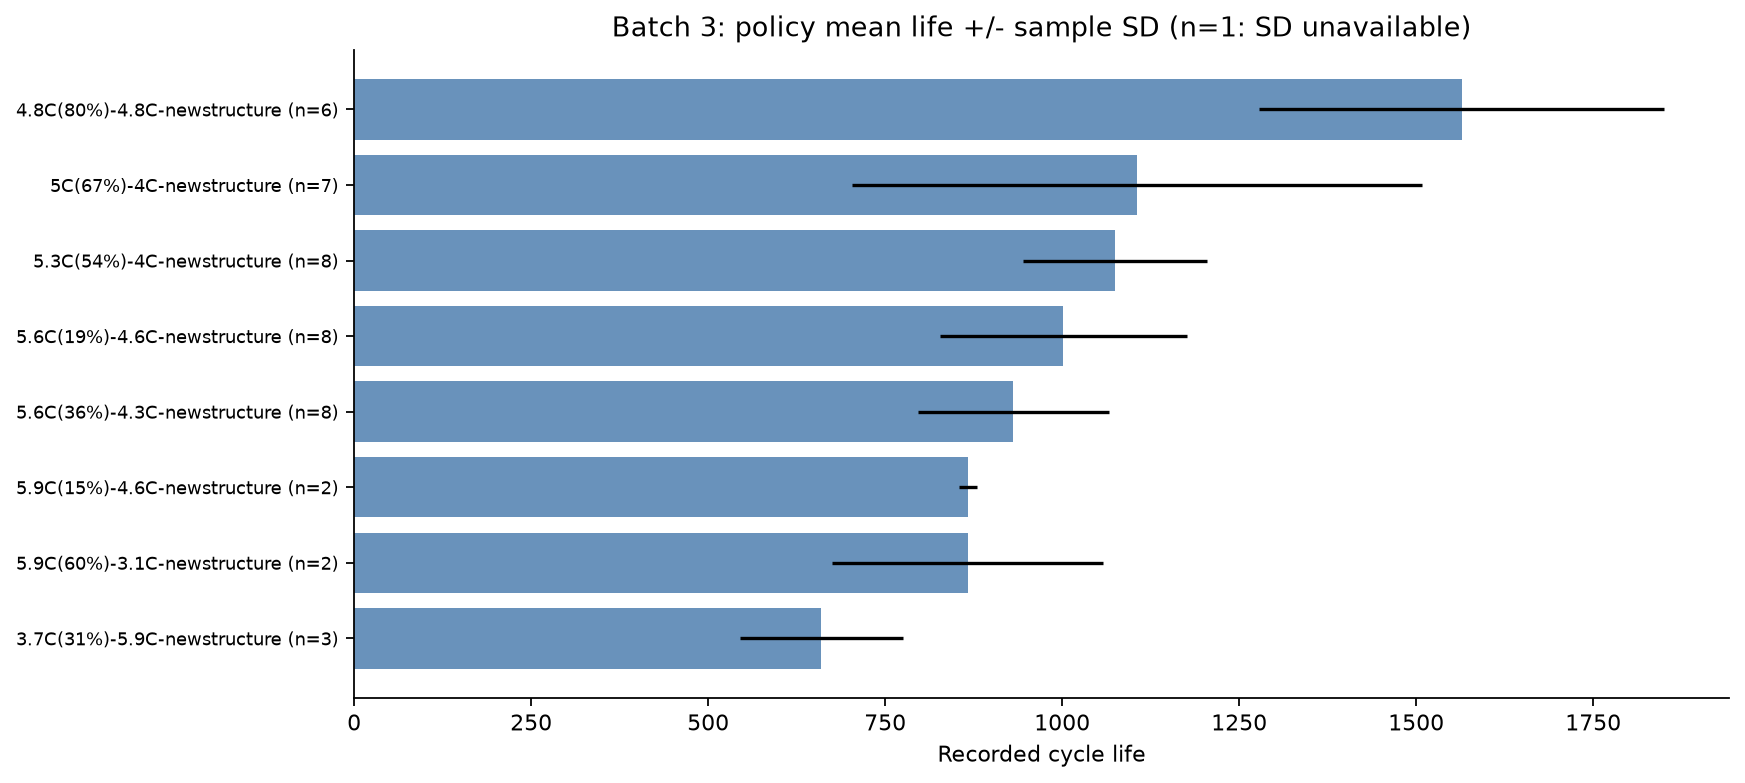

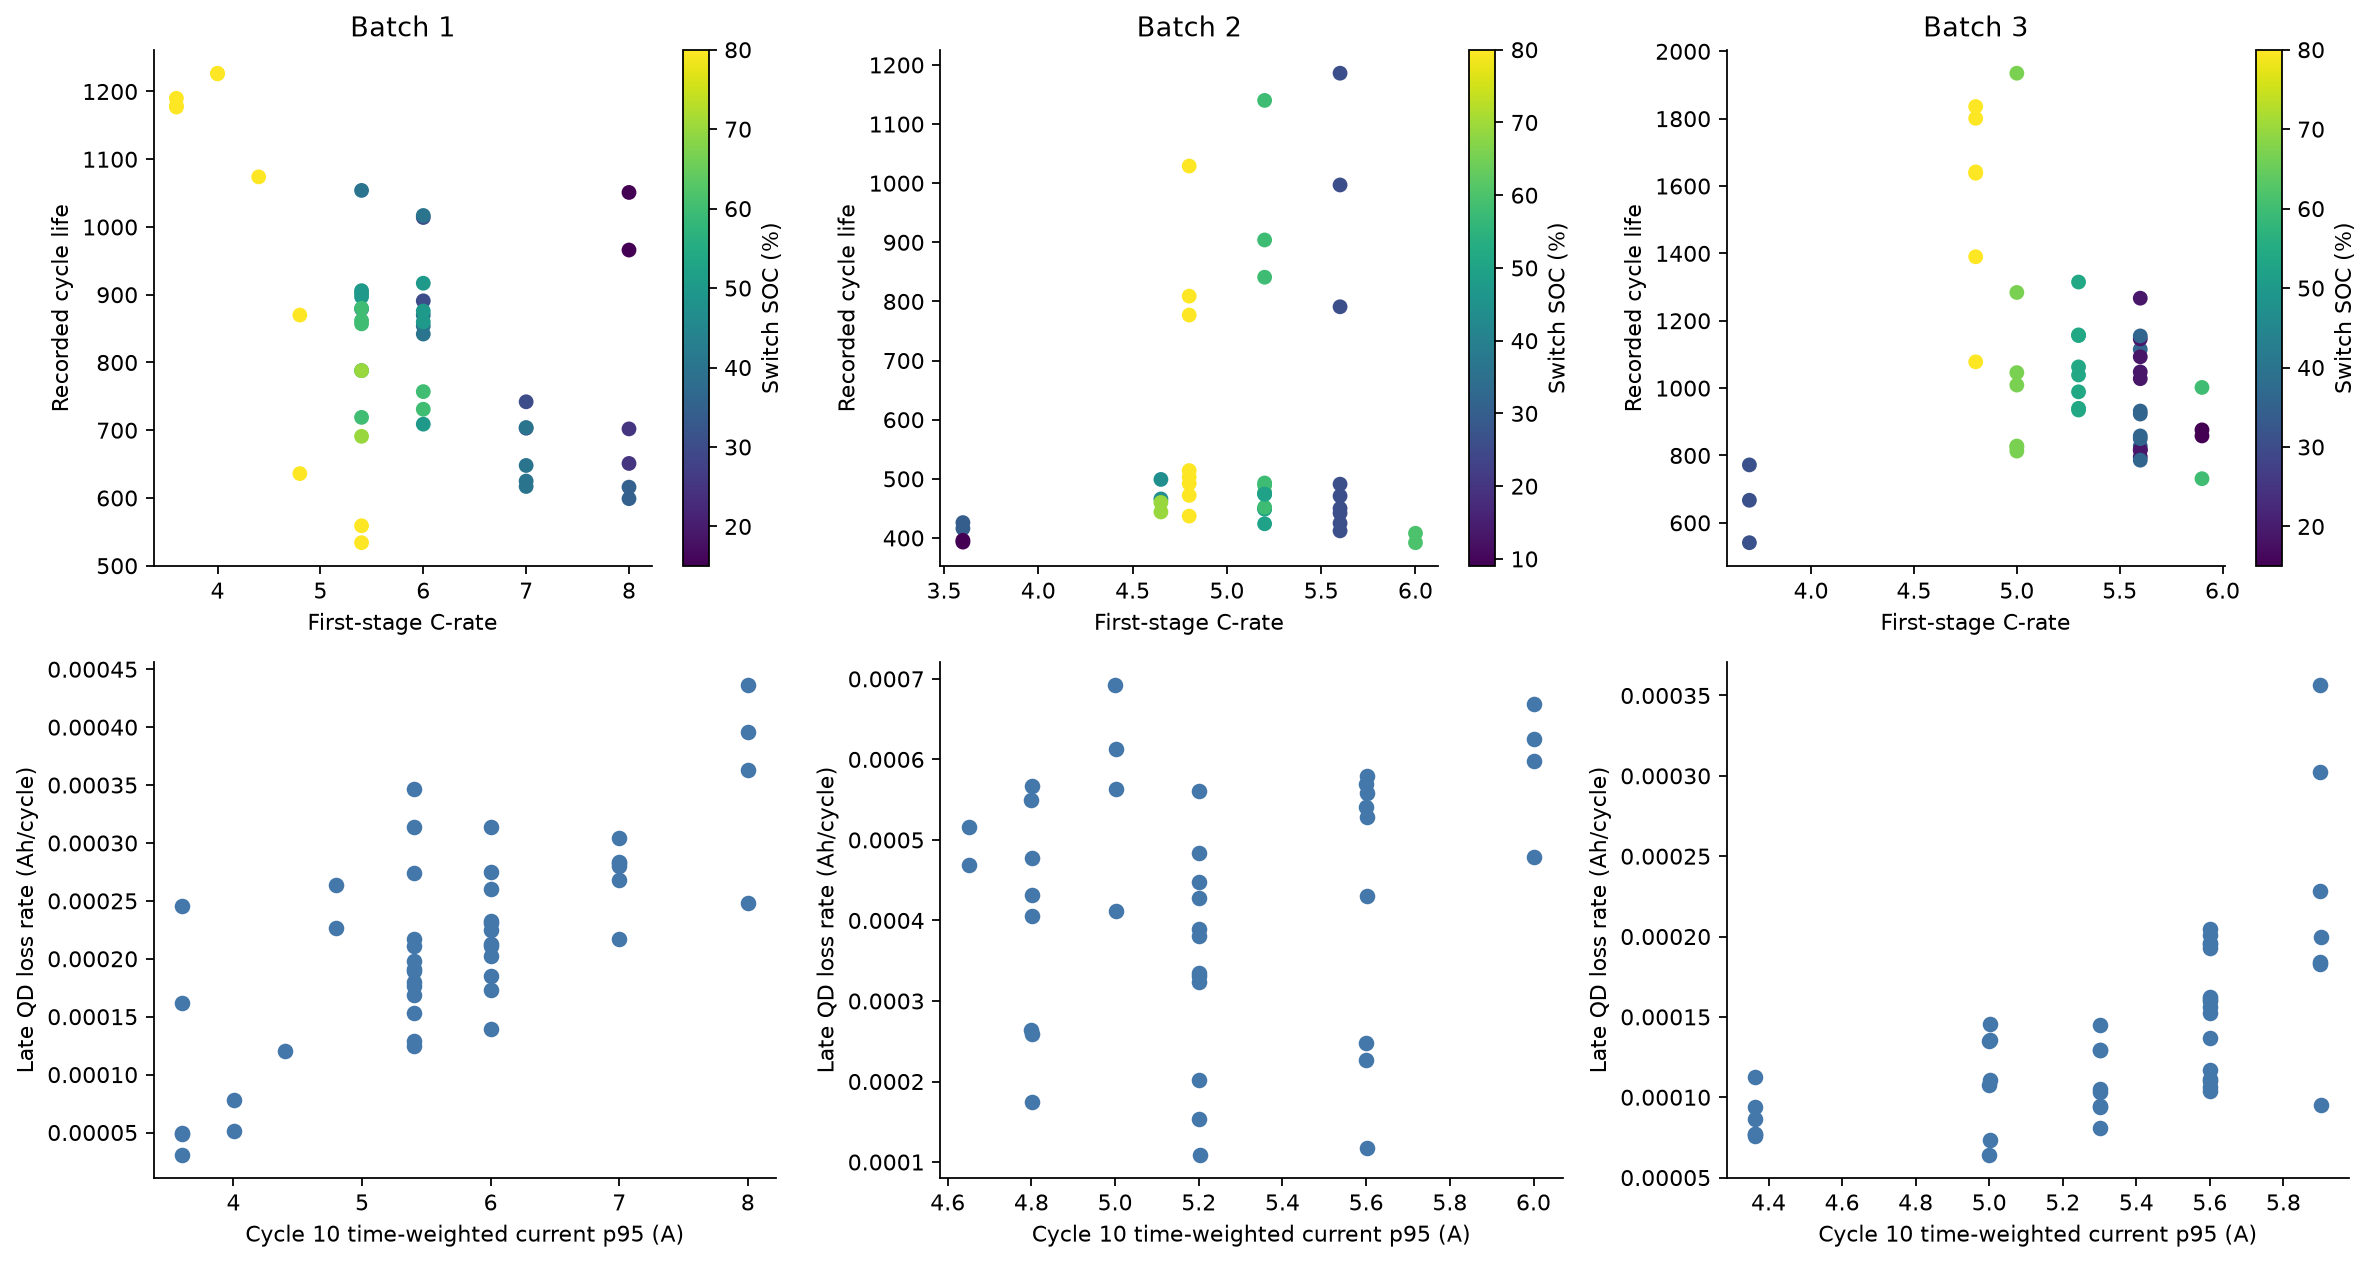

In [10]:
display(Image(filename=str(ROOT / "results/eda/figures/06_policy_b1.png")))
display(Image(filename=str(ROOT / "results/eda/figures/06_policy_b2.png")))
display(Image(filename=str(ROOT / "results/eda/figures/06_policy_b3.png")))
display(Image(filename=str(ROOT / "results/eda/figures/07_current.png")))

### 질문 10. Batch 1의 충전 조건과 수명

- 첫 C-rate–수명 ρ=−0.483입니다. 정책별 평균 수명은 `5.4C(80%)-5.4C` 546.5회, `4C(80%)-4C` 1226.5회입니다. 후자는 높은 종료 용량에 따른 라벨 해석의 한계가 있습니다.
- 같은 8C→3.6C도 전환 비율 15%·25%·35%에서 평균 1008.5·676.5·607.5회로 달랐습니다(각 n=2). 전류 p95–후기 감소 속도 ρ=+0.728입니다.
- 첫·둘째 C-rate와 전환 비율을 함께 검토합니다. 적은 표본의 관찰을 인과 효과로 단정하지 않습니다.

### 질문 11. Batch 2의 충전 조건과 수명

- 첫 C-rate–수명 ρ=+0.055로 관계가 약합니다. `4.8C(80%)-4.8C`의 평균은 483.6회(n=5), `newstructure` 표기가 있는 집단은 871.7회(n=3)입니다.
- 전류 p95–후기 감소 속도 ρ=+0.125입니다. 첫 속도가 낮은 `3.6C(9%)-5C`도 평균 394.5회로 짧았습니다.
- 첫 속도만으로 판단하지 않고 전체 충전 조건과 부가 표기를 구분합니다. 부가 표기의 물리적 의미는 확정하지 않습니다.

### 질문 12. Batch 3의 충전 조건과 수명

- 첫 C-rate–수명 ρ=−0.229입니다. 정책별 평균은 `4.8C(80%)-4.8C-newstructure` 1564.2회(n=6), `3.7C(31%)-5.9C-newstructure` 660.0회(n=3)입니다.
- 전류 p95–후기 감소 속도 ρ=+0.708입니다. 모든 라벨 셀에 `newstructure`가 있어 배치 안에서 표기 효과는 비교할 수 없습니다.
- 정책 조합과 실제 전류의 추가 예측력을 비교합니다. 후기 감소 속도는 해석에만 사용합니다.

## 5. 피처 상관과 다중공선성

VIF는 ΔQ 로그 분산·QD 기울기·평균/최고온도·전류 p95·첫 C-rate·전환 비율 조합에서 계산. VIF는 함께 넣는 변수에 따라 달라지기에 상관만으로 예측 성능이나 인과를 판단할 수는 없습니다.

In [11]:
display(tables['correlations'])
display(tables['vif'])
display(tables['feature_distributions'])

,batch,feature,n,spearman,pearson
0,Batch 1,delta_log_var,46,-0.871161,-0.886123
1,Batch 1,delta_mean,46,0.828112,0.853810
2,Batch 1,delta_min,46,0.850006,0.881645
3,Batch 1,delta_std,46,-0.871161,-0.893713
4,Batch 1,QD_mean,46,0.185025,0.193393
5,Batch 1,QD_median,46,0.215986,0.202685
6,Batch 1,QD_std,46,0.052794,-0.058478
7,Batch 1,QD_slope,46,0.586222,0.509897
8,Batch 1,IR_mean,46,0.135500,0.176631
9,Batch 1,IR_slope,46,-0.402985,0.092932


,batch,feature,n,VIF
0,Batch 1,delta_log_var,46,5.778235
1,Batch 1,QD_slope,46,1.927475
2,Batch 1,Tavg_mean,46,21.779662
3,Batch 1,Tmax_mean,46,17.581128
4,Batch 1,charge_I_p95,46,3.021920
5,Batch 1,rate1_C,46,10.020945
6,Batch 1,switch_pct,46,7.498317
7,Batch 2,delta_log_var,39,2.352258
8,Batch 2,QD_slope,39,1.711544
9,Batch 2,Tavg_mean,39,9.725049


,batch,feature,n,missing,mean,std,median,q1,q3,min,max
0,Batch 1,IR_mean,46,0,1.652275e-02,0.000490,1.658971e-02,1.629534e-02,1.673757e-02,0.014938,0.018005
1,Batch 1,IR_slope,46,0,8.728833e-07,0.000007,1.993433e-06,1.363456e-06,2.430797e-06,-0.000047,0.000003
2,Batch 1,QD_mean,46,0,1.082307e+00,0.007106,1.082344e+00,1.080134e+00,1.086247e+00,1.060084,1.097068
3,Batch 1,QD_median,46,0,1.082106e+00,0.007387,1.082465e+00,1.078420e+00,1.085804e+00,1.060556,1.097334
4,Batch 1,QD_slope,46,0,-2.008693e-05,0.000028,-1.570625e-05,-2.250142e-05,-5.762348e-06,-0.000157,0.000012
5,Batch 1,QD_std,46,0,5.950648e-03,0.027453,8.670479e-04,7.280693e-04,1.123431e-03,0.000581,0.182521
6,Batch 1,Tavg_mean,46,0,3.261656e+01,0.916932,3.280162e+01,3.207957e+01,3.330687e+01,29.942199,33.894970
7,Batch 1,Tmax_mean,46,0,3.586826e+01,1.615958,3.615714e+01,3.502693e+01,3.687021e+01,30.662263,37.990240
8,Batch 1,charge_I_mean,46,0,1.906024e+00,0.074715,1.907103e+00,1.868490e+00,1.966313e+00,1.670611,2.046890
9,Batch 1,charge_I_p95,46,0,5.687101e+00,1.199540,5.400517e+00,5.400182e+00,6.000342e+00,3.600178,7.999949


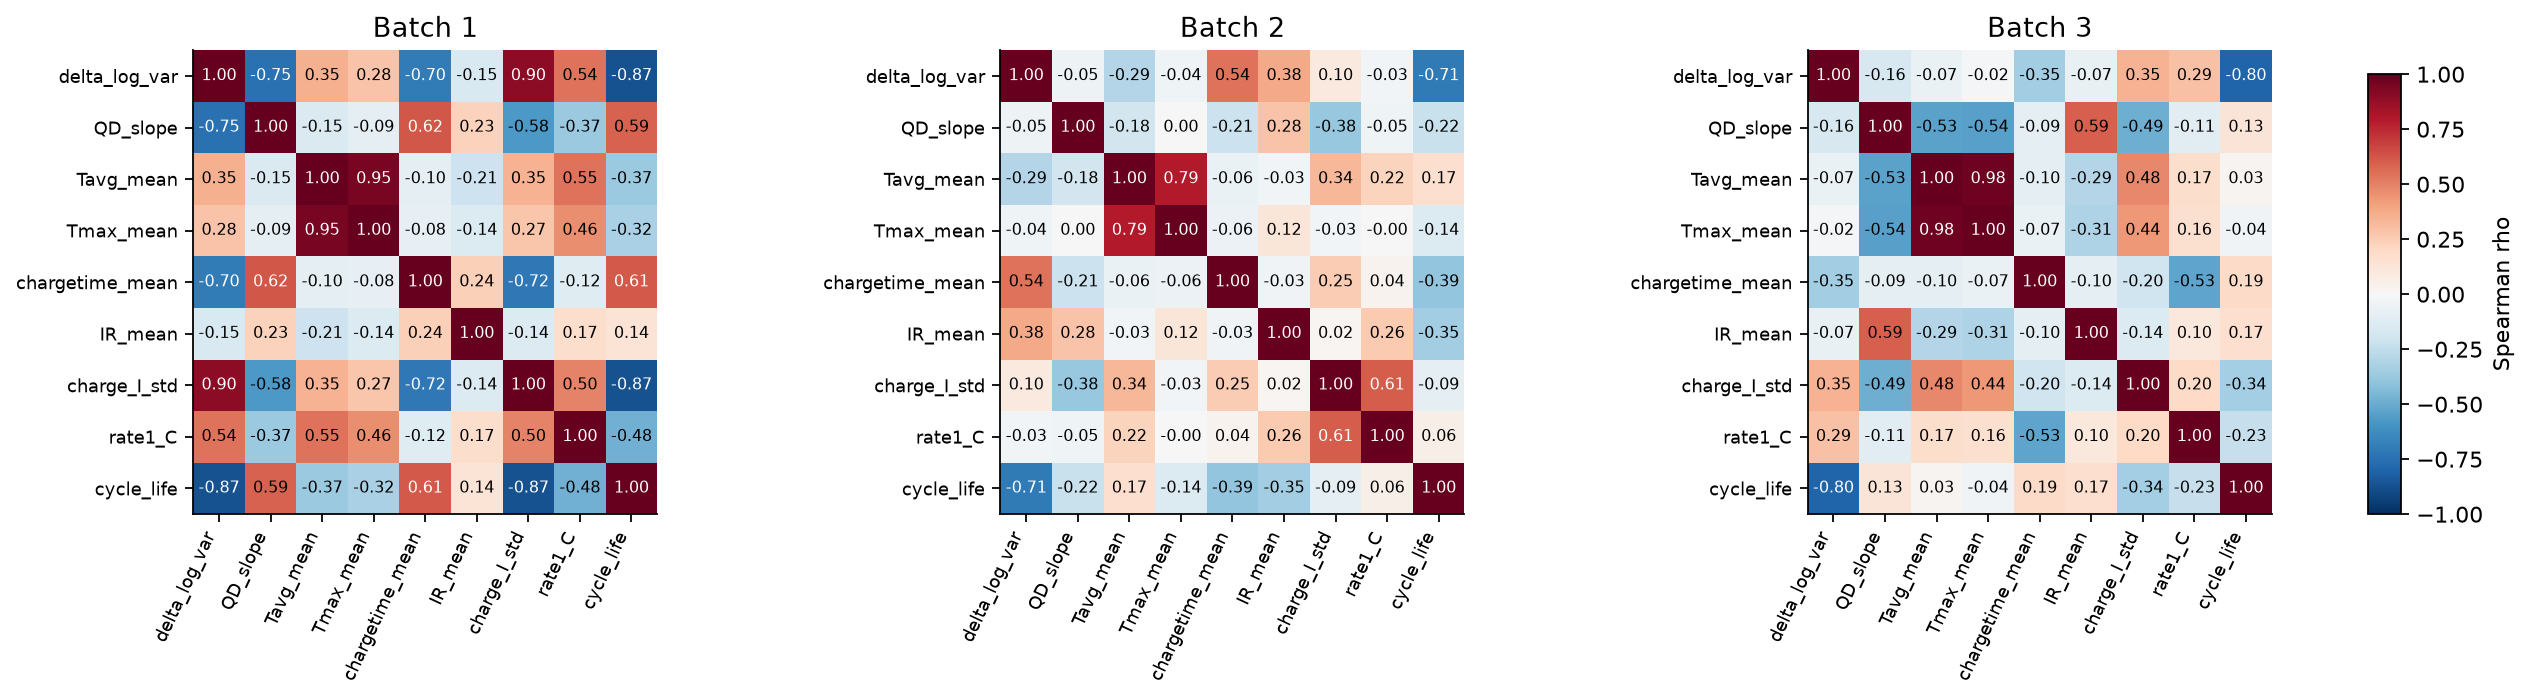

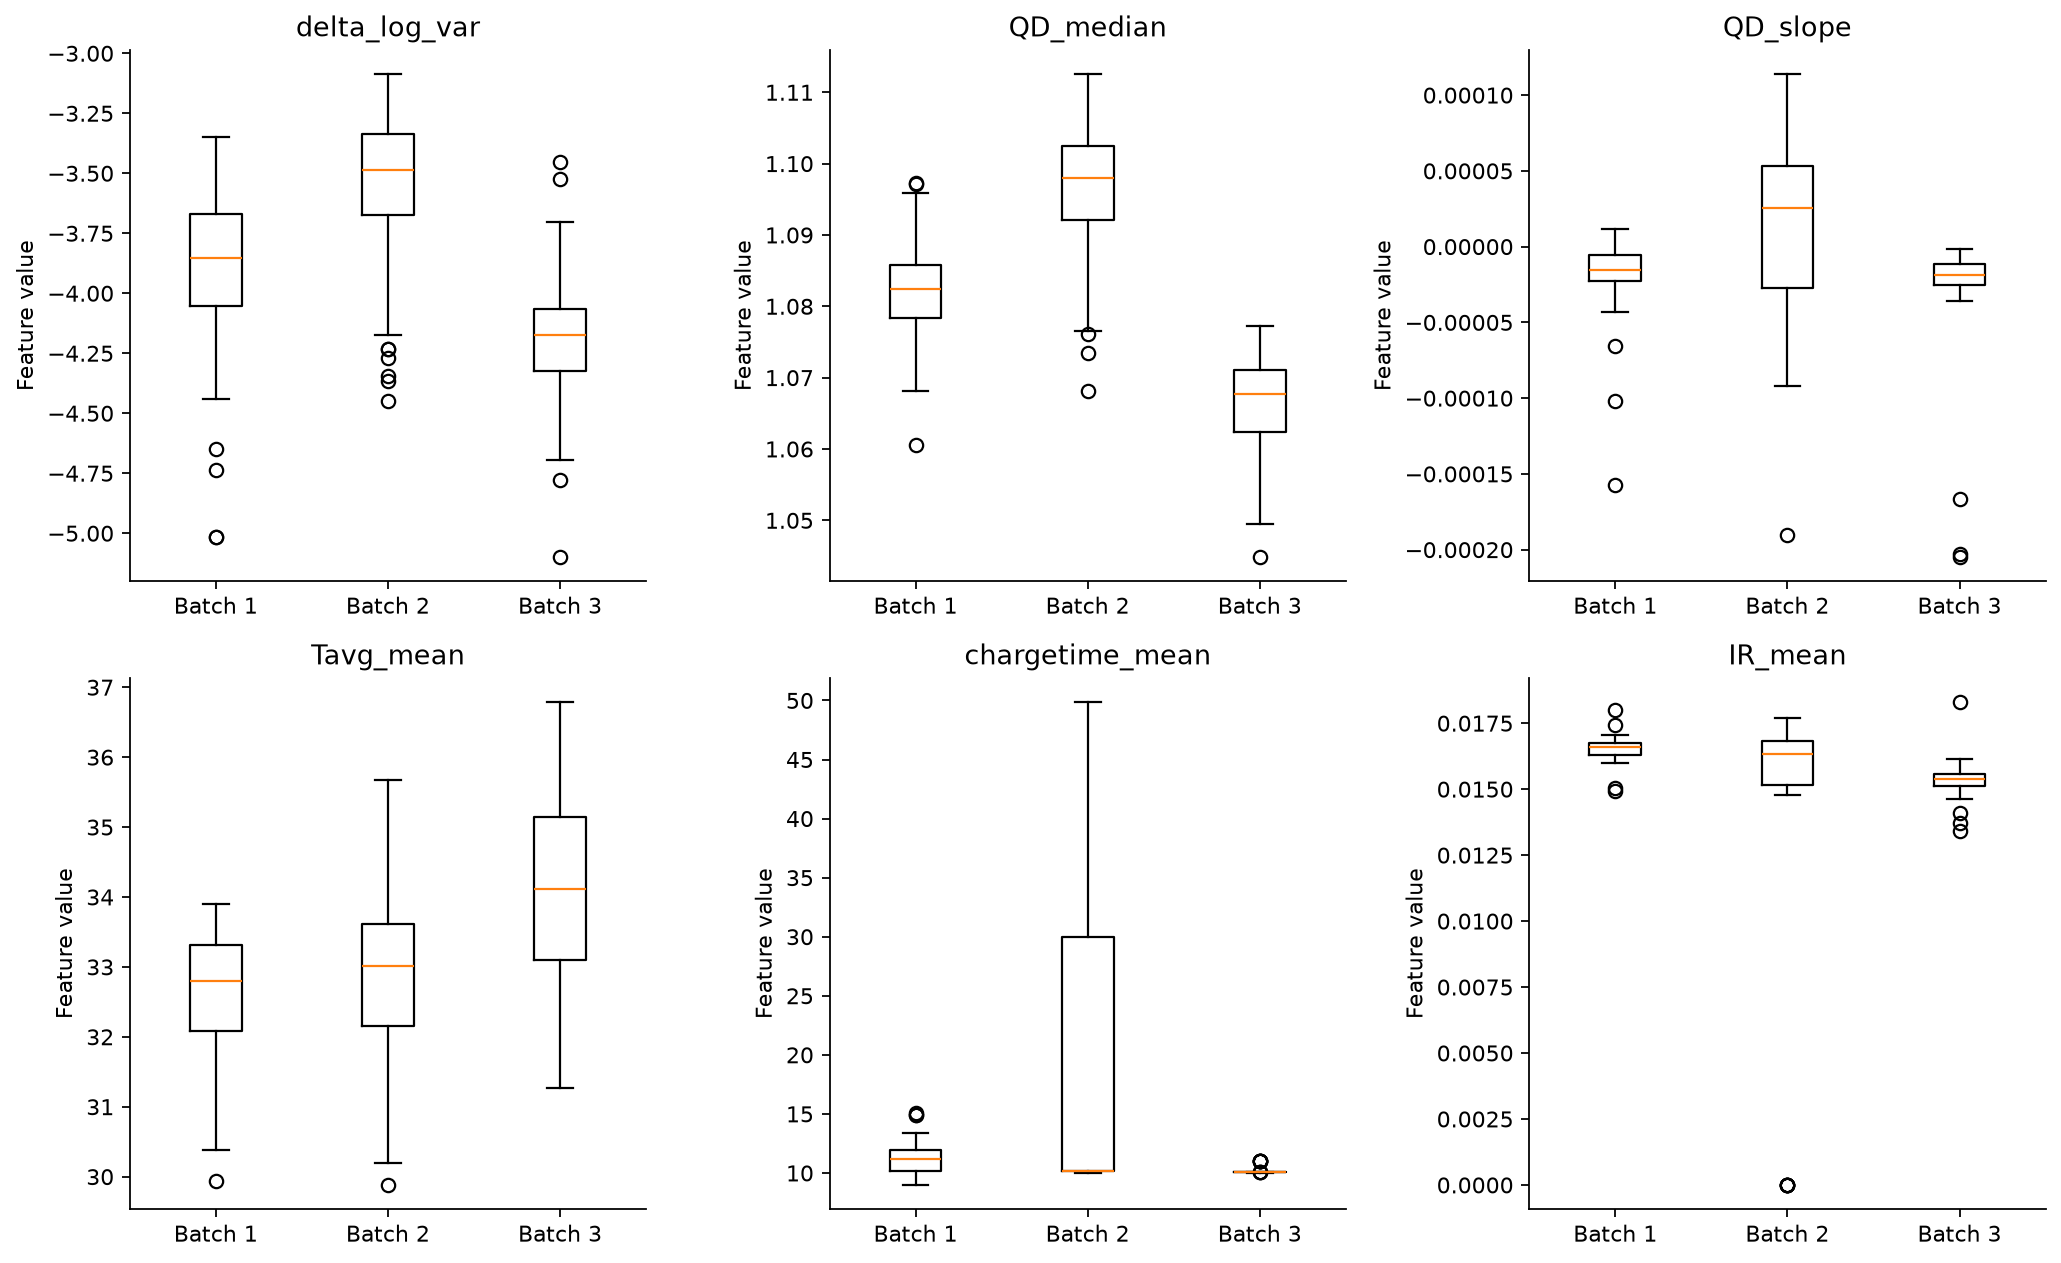

In [12]:
display(Image(filename=str(ROOT / "results/eda/figures/08_correlations.png")))
display(Image(filename=str(ROOT / "results/eda/figures/09_feature_distributions.png")))

### 질문 13. Batch 1의 주요 초기 신호와 다중공선성

- 전류 표준편차–수명 ρ=−0.874, ΔQ 로그 분산–수명 ρ=−0.871로 강도가 비슷합니다.
- 평균·최고온도 상관은 +0.951, VIF는 21.78·17.58로 중복이 큽니다.
- ΔQ 대표 통계와 온도 하나부터 검토하고, 전류의 추가 효과는 규제 모델과 그룹 CV로 확인합니다.

### 질문 14. Batch 2의 주요 초기 신호와 다중공선성

- ΔQ 로그 분산–수명 ρ=−0.709입니다. 전류 평균(+0.538)과 충전시간(−0.393)은 Batch 1과 부호가 다릅니다.
- IR이 초기 구간 전체에서 0인 셀은 7개(라벨 셀 6개)이며 0의 의미는 불확실합니다. 온도 VIF는 9.73·7.00입니다.
- IR은 기본 입력에서 보류합니다. 다른 배치에서 관계가 유지되는지도 확인합니다.

### 질문 15. Batch 3의 주요 초기 신호와 다중공선성

- ΔQ 로그 분산–수명 ρ=−0.797, 전류 p95는 −0.601입니다. 평균온도(+0.025)와 충전시간(+0.192)의 관계는 약합니다.
- 온도 간 상관은 +0.976, VIF는 23.88·21.64입니다. QD 기울기·첫 C-rate·전류 p95도 VIF가 14.90~16.78로 중복됩니다.
- 대표 변수와 규제를 사용하고 피처 묶음별로 비교합니다. 배치를 합친 상관과 배치 내부 상관은 구분합니다.

## 6. 모델 설계 요약

### 피처 선정

ΔQ 로그 분산을 기본 입력으로 두고, 같은 분할에서 추가 피처의 효과를 비교합니다.

| 묶음 | 입력 피처 |
| --- | --- |
| A | ΔQ 로그 분산 |
| B | A + 초기 QD 중앙값·기울기 |
| C | A + 온도 하나 |
| D | A + 정책 숫자·부가 표기 |
| E | A + cycle 10 전류 통계 |

- ΔQ 요약·온도 변수의 중복을 줄이고 IR·충전시간은 보조 후보로 둡니다.
- QD100−QD10·상대 변화·정책 결합항은 Day 2 추가 추출 후보입니다.
- 전체 기록 길이·마지막 QD·Knee·후기 기울기는 입력에서 제외합니다.

### 태스크와 후보 모델

- **회귀:** 초기 100사이클로 총수명 `cycle_life`를 예측합니다. Batch 1에는 <500회 셀이 없어 해당 기준의 분류 학습이 어렵습니다.
- **타깃:** 원래 수명과 로그 수명을 비교하고 로그 예측은 원래 단위로 되돌려 평가합니다.
- **후보:** 중앙값 기준선, ΔQ 선형 회귀, Ridge·ElasticNet, 얕은 Random Forest·Gradient Boosting. 작은 표본과 중복을 고려해 선형·규제 모델부터 검토합니다.

### 검증과 평가

1. Batch 1에서 정책 그룹별로 Hold-out을 분리합니다.
2. 남은 셀의 그룹 CV MAPE로 피처·모델·파라미터를 선택합니다.
3. 선택 모델의 Hold-out 성능을 확인한 후 Batch 1 전체로 재학습합니다.
4. Batch 2에서 최종 평가하며 Batch 3는 선택적으로 추가 평가합니다. 평가 점수로 모델을 재조정하지 않습니다.

**주 지표는 MAPE, 보조 지표는 MAE·RMSE**입니다. CV·Hold-out·Batch 2 성능과 Gap을 보고하고 과제 목표 MAPE 9.1%와 비교해야합니다.
